In [1]:
from pyns.nsfile import NSFile
from pathlib import Path
import numpy as np
import pandas as pd
import smile_extract
import matplotlib.pyplot as plt
import seaborn as sns
from src.process_ripple import compose_ripple_smile

In [2]:
monkey = "Prez"
date = "2025-12-11"
task = "memory-guided-reach-stim"
folder = Path(f"/Users/raeed/Library/CloudStorage/OneDrive-UniversityofPittsburgh/0-projects/cortex-stim/data/{monkey}/{date}")
nev_filename = folder / f"{monkey}_{date}_{task}_neural.nev"
smile_file = folder / f"{monkey}_{date}_{task}_behavior.mat"
nsfile = NSFile(str(nev_filename))
smile_data = smile_extract.direct_load_smile_data(str(smile_file))

In [3]:
trialframe = compose_ripple_smile(
    nsfile,
    smile_data,
    bin_size='1ms',
    monkey=monkey,
    start_target_name='touchbarcircle',
    end_target_name='reachtargettouchbarmg',
)
trialframe

/Users/raeed/codebase/0-projects/smile-extraction/smile_extract/composition.py:61: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  return pd.concat(
/Users/raeed/codebase/0-projects/smile-extraction/smile_extract/composition.py:61: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat(


signal                                                                                                  hand position  \
channel                                                                                                             x   
trial_id time                   stim trial result  target direction state            stimulated channel                 
1        0 days 00:00:00        True       failure 180              Reach to Center  (M1.chan036)            7.118629   
         0 days 00:00:00.001000 True       failure 180              Reach to Center  (M1.chan036)            7.118653   
         0 days 00:00:00.002000 True       failure 180              Reach to Center  (M1.chan036)            7.118508   
         0 days 00:00:00.003000 True       failure 180              Reach to Center  (M1.chan036)            7.118178   
         0 days 00:00:00.004000 True       failure 180              Reach to Center  (M1.chan036)            7.117666   
...                                                                                                               ...   
721      0 days 00:00:06.502000 True       failure 180              Failure (Center) ()                           NaN   
         0 days 00:00:06.503000 True       failure 180              Failure (Center) ()                           NaN   
         0 days 00:00:06.504000 True       failure 180              Failure (Center) ()                           NaN   
         0 days 00:00:06.505000 True       failure 180              Failure (Center) ()                           NaN   
         0 days 00:00:06.506000 True       failure 180              end              ()                           NaN   

signal                                                                                                              \
channel                                                                                                          y   
trial_id time                   stim trial result  target direction state            stimulated channel              
1        0 days 00:00:00        True       failure 180              Reach to Center  (M1.chan036)        11.752441   
         0 days 00:00:00.001000 True       failure 180              Reach to Center  (M1.chan036)        11.751835   
         0 days 00:00:00.002000 True       failure 180              Reach to Center  (M1.chan036)        11.751293   
         0 days 00:00:00.003000 True       failure 180              Reach to Center  (M1.chan036)        11.750889   
         0 days 00:00:00.004000 True       failure 180              Reach to Center  (M1.chan036)        11.750702   
...                                                                                                            ...   
721      0 days 00:00:06.502000 True       failure 180              Failure (Center) ()                        NaN   
         0 days 00:00:06.503000 True       failure 180              Failure (Center) ()                        NaN   
         0 days 00:00:06.504000 True       failure 180              Failure (Center) ()                        NaN   
         0 days 00:00:06.505000 True       failure 180              Failure (Center) ()                        NaN   
         0 days 00:00:06.506000 True       failure 180              end              ()                        NaN   

signal                                                                                                              \
channel                                                                                                          z   
trial_id time                   stim trial result  target direction state            stimulated channel              
1        0 days 00:00:00        True       failure 180              Reach to Center  (M1.chan036)       -42.850975   
         0 days 00:00:00.001000 True       failure 180              Reach to Center  (M1.chan036)       -42.851976   
         0 days 00:00:00.002000 True       failure 180        

In [4]:
neural_data = (
    pd.DataFrame(trialframe['neural activity'])
    .rename_axis('recorded channel',axis=1)
    .sort_index(axis=1)
)

pass
False    88
True     40
Name: count, dtype: int64

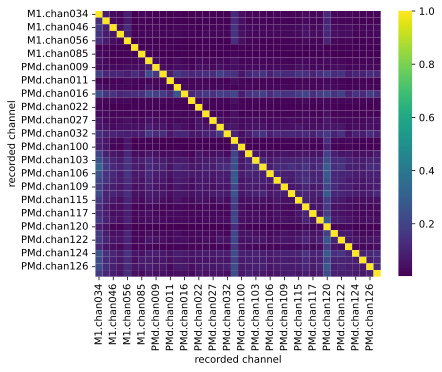

In [5]:
from src.process_ripple import get_channel_stats
spike_mat = (
    neural_data
    .xs(level='stim trial',key=False)
)
channel_stats = get_channel_stats(spike_mat, max_fano=1000, max_coincidence=0.5)
spike_mat_select = (
    spike_mat
    .loc[:, channel_stats.index[channel_stats['pass']]]
    .fillna(0) # sometimes there's missing data, maybe from some packet drops in Trellis?
)
select_coincidence = (
    (spike_mat_select.T @ spike_mat_select)
    / spike_mat_select.sum(axis=0)
)
sns.heatmap(select_coincidence, cmap='viridis')
channel_stats['pass'].value_counts()

In [6]:
from src.time_slice import get_epoch_data,multivalue_xs
hand_data = trialframe['hand position']
movement = (
    hand_data
    .xs(level='result',key='success')
    .pipe(multivalue_xs,level='stimulated channel',keys=[frozenset(),frozenset({'PMd.chan010'})])
    .pipe(get_epoch_data,epochs={
        'peri-go': ('Cheat Period',slice(pd.to_timedelta('-100ms'),pd.to_timedelta('1000ms'))),
    })
)

import altair as alt
alt.data_transformers.enable('json')
base_chart = (
    alt.Chart(
        movement
        .stack()
        .rename('position')
        .reset_index()
        .assign(
            time=lambda df: df['time'].dt.total_seconds(),
        )
        .assign(**{
            'stimulated channel': lambda df: df['stimulated channel'].map(lambda x: str(set(x)).strip("{}").replace("'", "   ").replace(", "," ").replace("M1","  M1")),
        })
    )
    # .configure_axis(grid=False)
    # .configure_view(stroke=None)
)
traces = (
    base_chart
    .mark_errorband(extent='ci')
    .encode(
        x='time:Q',
        y=alt.Y('position:Q',scale=alt.Scale(zero=False)),
        # detail='trial_id:O',
        color=alt.Color('stimulated channel:N',sort=['PMd.chan010','set()']),
    )
)

stim_boundary = (
    base_chart
    .mark_rule(color='purple',strokeDash=[4,4])
    .encode(
        y=alt.value(30),
    )
)

(
    traces
    .facet(
        row='target direction:N',
        column='channel:N',
    )
    .configure_axis(grid=False)
    .configure_view(stroke=None)
)

alt.FacetChart(...)

In [119]:
from trialframe.timeseries import smooth_data
stim_response = (
    neural_data
    [channel_stats.index[channel_stats['pass']]]
    .xs(level='result',key='success')
    .fillna(0) # sometimes there's missing data, maybe from some packet drops in Trellis?
    .pipe(get_epoch_data,{
        'pre-stim': ('stim',slice(pd.to_timedelta('-1000ms'),pd.to_timedelta('-50ms'))),
        'post-stim': ('stim',slice(pd.to_timedelta('200ms'),pd.to_timedelta('1000ms'))),
        'peri-go': ('Cheat Period',slice(pd.to_timedelta('-1200ms'),pd.to_timedelta('1000ms'))),
    }) #type: ignore
    .div(1e-3)  # convert to firing rate in Hz
    .groupby(['trial_id','target direction','phase','stimulated channel'],observed=True,group_keys=False)
    .apply(smooth_data,std=pd.Timedelta('20ms'),kernel='beta',causal=True)
)

In [121]:
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from trialframe import SoftnormScaler, DataFrameTransformer, slice_by_time

# Truncate trials to common length within each phase to avoid NaNs
def truncate_to_common_length(df):
    """Truncate each trial to the minimum trial length within the group."""
    min_length = df.groupby(['trial_id'],observed=True).size().min()
    return df.groupby(['trial_id'],observed=True, group_keys=False).head(min_length)

latent_pipeline = make_pipeline(
    SoftnormScaler(),
    DataFrameTransformer(PCA(n_components=3)),
)

latent_pipeline.fit(
    stim_response
    .xs(level='stimulated channel',key=frozenset())
    .groupby(['target direction','phase','time'],observed=True)
    .mean()
)

stim_pca = latent_pipeline.transform(stim_response)

trajectories = (
    alt.Chart(
        stim_pca
        .pipe(multivalue_xs,level='trial_id',keys=[95,19])
        .pipe(multivalue_xs,level='stimulated channel',keys=[frozenset(),frozenset({'PMd.chan010'})])
        .xs(level='phase',key='peri-go')
        # .pipe(multivalue_xs,level='phase',keys=['pre-stim','post-stim'])
        # .pipe(slice_by_time, time_slice=slice(pd.to_timedelta('-150ms'), pd.to_timedelta('300ms')))
        # .groupby(['phase'],observed=True, group_keys=False)
        # .apply(truncate_to_common_length)
        # .groupby(['target direction','phase','stimulated channel','time'],observed=True)
        # .mean()
        .xs(level='target direction',key=180)
        .rename(columns=lambda col: f'component {col}')
        # .rename_axis('latent dimension',axis=1)
        # .stack()
        # .rename('activity')
        .reset_index()
        .assign(
            time=lambda df: df['time'].dt.total_seconds(),
        )
        .assign(**{
            'stimulated channel': lambda df: df['stimulated channel'].map(lambda x: str(set(x)).strip("{}").replace("'", "   ").replace(", "," ").replace("M1","  M1")),
        })
    )
    # .mark_point(size=5, opacity=0.3)
    .mark_line(opacity=1)
    .encode(
        x=alt.X('component 0:Q', scale=alt.Scale(domain=[-2.5, 2.5], clamp=True)),
        y=alt.Y('component 1:Q', scale=alt.Scale(domain=[-1.25, 1.25], clamp=True)),
        # x='time:Q',
        # y='activity:Q',
        color='state:N',
        # color=alt.Color('stimulated channel:N',sort=['PMd.chan010','set()']),
        # color='stimulated channel:N',
        # detail='phase:N',
        order='time:Q',
        # detail='trial_id:N',
    )
    .facet(
        # column=alt.Column('phase:N', sort=['pre-stim','post-stim']),
        # row='trial_id:N',
        column='stimulated channel:N',
        # row='latent dimension:N',
    )
)
trajectories

alt.FacetChart(...)

<Axes: >

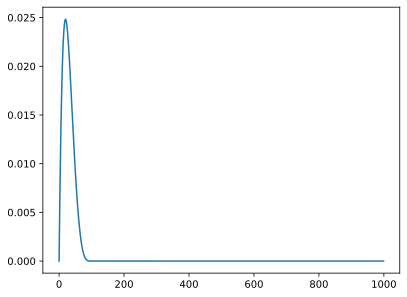

In [118]:
from scipy.ndimage import convolve1d
from trialframe.smoothing import beta_window
win = beta_window(1,10)
temp = convolve1d(np.array([1]+[0]*999),win,axis=0,output=np.float32, mode='constant', cval=0.0, origin=-(len(win)-1)//2)
sns.lineplot(x=np.arange(len(temp)),y=temp)

In [ ]:
kfrom sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import make_pipeline
from src.time_slice import get_index_level
from trialframe import SoftnormScaler

# Find dimension that best separates target directions
target_lda = make_pipeline(
    SoftnormScaler(),
    LinearDiscriminantAnalysis(n_components=1)
)
target_lda.fit(
    stim_response
    .xs(level='stimulated channel',key=frozenset())
    .xs(level='phase',key='post-stim')
    .groupby(['trial_id','target direction','time'],observed=True)
    .mean(),
    stim_response
    .xs(level='stimulated channel',key=frozenset())
    .xs(level='phase',key='post-stim')
    .groupby(['trial_id','target direction','time'],observed=True)
    .mean()
    .pipe(get_index_level, 'target direction')
)

# Find dimension that best separates stimulated vs non-stimulated trials
stim_lda = make_pipeline(
    SoftnormScaler(),
    LinearDiscriminantAnalysis(n_components=1)
)
stim_lda.fit(
    stim_response
    .xs(level='phase',key='post-stim')
    .groupby(['trial_id','target direction','stimulated channel','time'],observed=True)
    .mean(),
    stim_response
    .xs(level='phase',key='post-stim')
    .groupby(['trial_id','target direction','stimulated channel','time'],observed=True)
    .mean()
    .pipe(get_index_level, 'stimulated channel')
    .map(lambda x: 'stim' if x != frozenset() else 'no-stim')
)

# Project all data onto these two dimensions

target_proj = pd.DataFrame(
    target_lda.transform(stim_response),
    index=stim_response.index,
    columns=['target dimension']
)

stim_proj = pd.DataFrame(
    stim_lda.transform(stim_response),
    index=stim_response.index,
    columns=['stim dimension']
)

lda_projections = pd.concat([target_proj, stim_proj], axis=1)

# Create plot
lda_trajectories = (
    alt.Chart(
        lda_projections
        #.pipe(multivalue_xs,level='trial_id',keys=[95,19])
        .pipe(multivalue_xs,level='phase',keys=['pre-stim','post-stim'])
        .xs(level='stimulated channel',key=frozenset({'PMd.chan010'}))
        .xs(level='target direction',key=180)
        .reset_index()
        .assign(
            time=lambda df: df['time'].dt.total_seconds(),
        )
        # .assign(**{
        #     'stimulated channel': lambda df: df['stimulated channel'].map(lambda x: str(set(x)).strip("{}").replace("'", "   ").replace(", "," ").replace("M1","  M1")),
        # })
    )
    .mark_line()
    .encode(
        x=alt.X('target dimension:Q', scale=alt.Scale(clamp=True)),
        y=alt.Y('stim dimension:Q', scale=alt.Scale(clamp=True)),
        color='state:N',
        # color='phase:N',
        order='time:Q',
        detail='trial_id:N',
    )
    .facet(
        column='trial_id:N',
    )
)
lda_trajectories

alt.FacetChart(...)

In [ ]:
from trialframe.dpca import PhaseConcatDPCA

dpca_pipeline = make_pipeline(
    SoftnormScaler(),
    PhaseConcatDPCA(
        conditions=['target direction','stimulated channel','time'],
        labels='dst',
        join={'s':['s','st'],'d':['d','dt'],'ds': ['ds','dst']},
        channel_level_name='recorded channel',
        n_components=6,
    )
)

dpca_result = dpca_pipeline.fit_transform(
    stim_response
    .pipe(multivalue_xs,level='stimulated channel',keys=[frozenset(),frozenset({'PMd.chan010'})])
    .pipe(multivalue_xs,level='phase',keys=['pre-stim','post-stim'])
    .groupby(['phase'],observed=True, group_keys=False)
    .apply(truncate_to_common_length)
)
(
    alt.Chart(
        dpca_result
        .rename_axis(['marginalization','component'],axis=1)
        .xs(level='target direction',key=180)
        .stack('marginalization')
        .stack('component')
        .rename('activity')
        .reset_index()
        .assign(
            time=lambda df: df['time'].dt.total_seconds(),
        )
        .assign(**{
            'stimulated channel': lambda df: df['stimulated channel'].map(lambda x: str(set(x)).strip("{}").replace("'", "   ").replace(", "," ").replace("M1","  M1")),
        })
    )
    .mark_line()
    .encode(
        x='time:Q',
        y='mean(activity):Q',
        #color='target direction:N',
        color='stimulated channel:N',
        detail='trial_id:N',
        row='marginalization:N',
        column='component:N',
    )
)

/Users/raeed/codebase/0-projects/trialframe/trialframe/dpca.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(conditions)
/Users/raeed/codebase/0-projects/trialframe/trialframe/dpca.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(conditions)
/Users/raeed/codebase/0-projects/trialframe/trialframe/dpca.py:93: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  .pipe(np.concatenate,axis=-1)  # Concatenate al

alt.Chart(...)

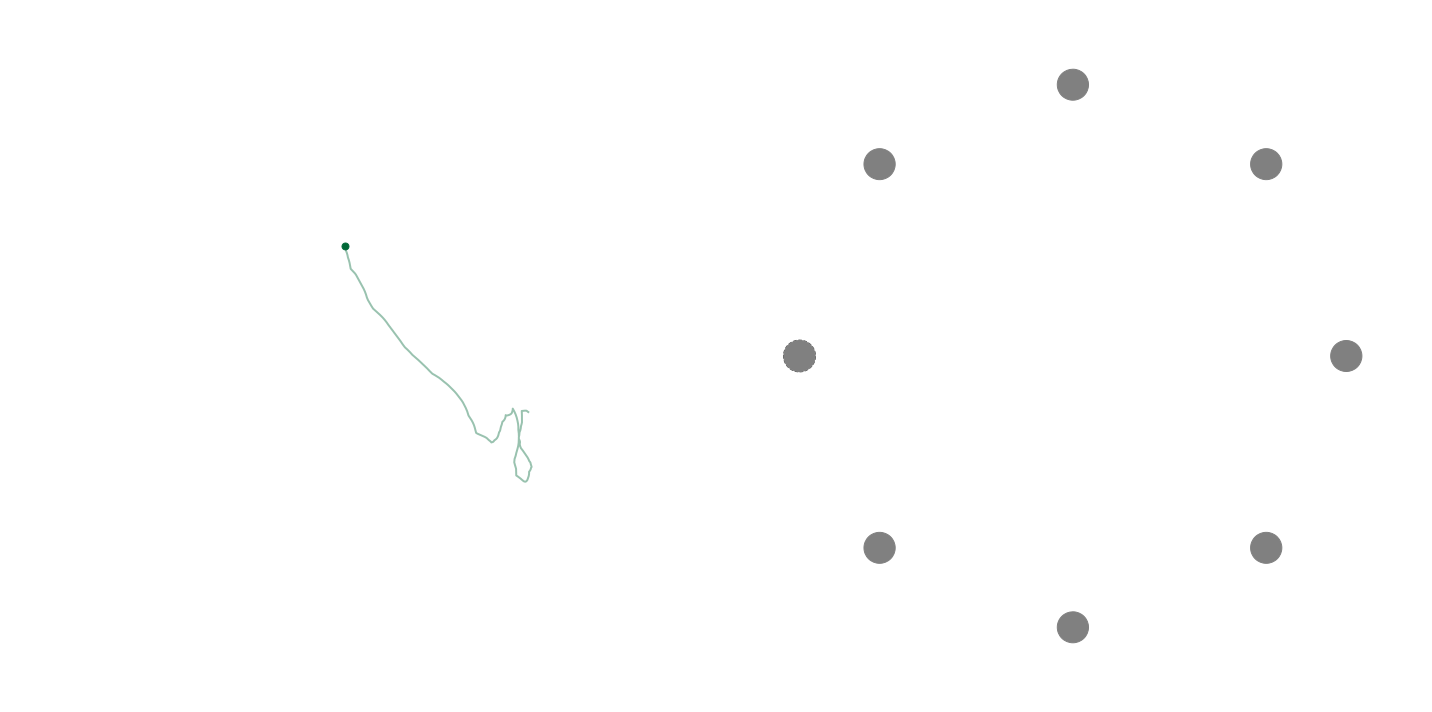

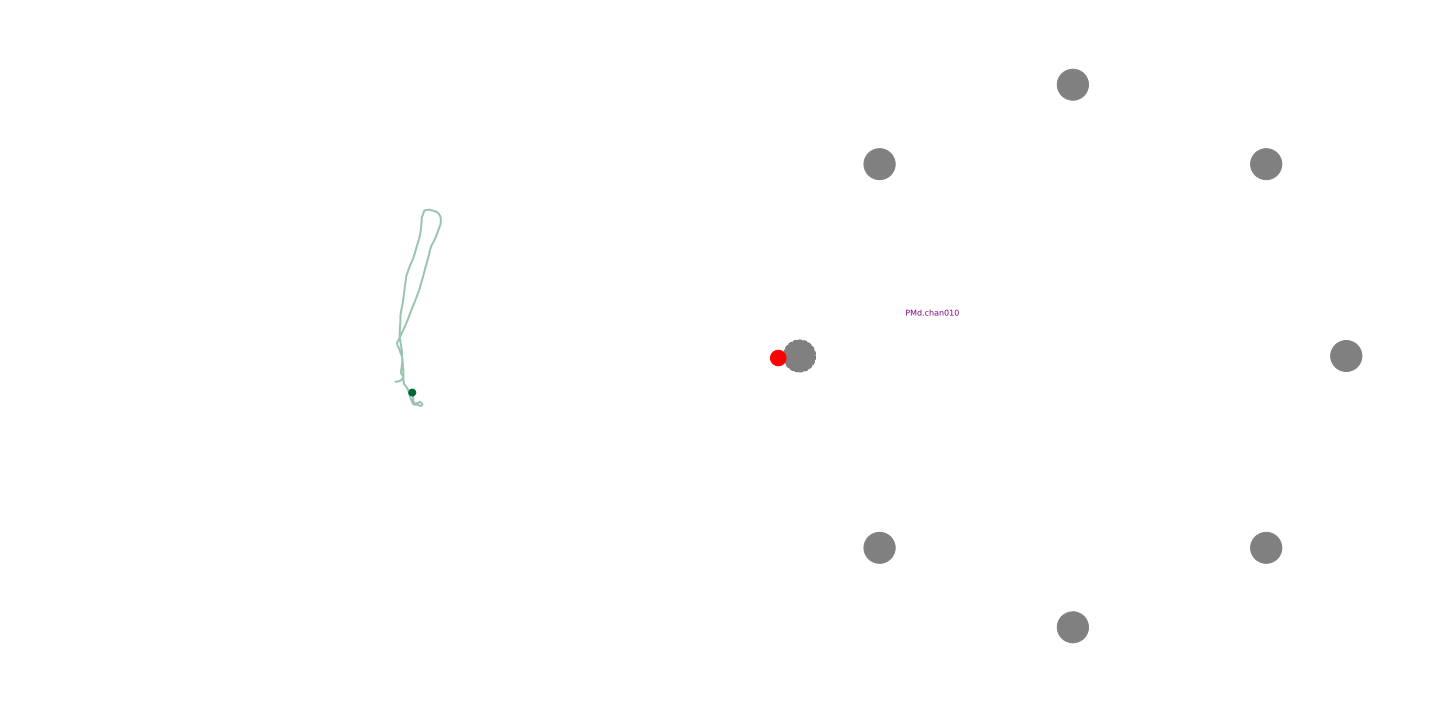

In [122]:
from src.animation import animate_trial
from trialframe import hierarchical_assign

def animate_selected_trial(trial_id):
    trial = (
        trialframe
        .pipe(multivalue_xs,level='trial_id',keys=[trial_id])
        .pipe(get_epoch_data,epochs={
            'peri-go': ('Cheat Period',slice(pd.to_timedelta('-1200ms'),pd.to_timedelta('1000ms'))),
        })
        .xs(level='phase',key='peri-go')
        .pipe(hierarchical_assign, {
            'neural pca': lambda df: (
                df['neural activity']
                [channel_stats.index[channel_stats['pass']]]
                .div(1e-3)  # convert to firing rate in Hz
                .groupby(['trial_id','target direction','stimulated channel'],observed=True, group_keys=False)
                .apply(smooth_data,std=pd.Timedelta('20ms'),kernel='beta',causal=True)
                .pipe(latent_pipeline.transform)
            )
        })
    )
    anim = animate_trial(trial, save_path=f'../results/{monkey}_{date}_{task}_trial{trial_id}_peri-go_neural_state_beta.mp4')
    return anim

trials_to_animate = [19,95]
anims = [animate_selected_trial(trial_id) for trial_id in trials_to_animate]

In [125]:
get_index_level(trialframe,level='stimulated channel').unique()

[('M1.chan036'), ('PMd.chan103'), ('PMd.chan126'), ('PMd.chan022'), ('PMd.chan100'), ..., ('PMd.chan006'), ('M1.chan046'), ('PMd.chan127'), ('M1.chan085'), ('PMd.chan116')]
Length: 39
Categories (39, object): [(), ('M1.chan036'), ('PMd.chan029'), ('PMd.chan016'), ..., ('PMd.chan023'), ('PMd.chan115'), ('PMd.chan009'), ('PMd.chan116')]

In [73]:
from trialframe import hierarchical_assign
trial_id = 95
temp = (
    trialframe
    .pipe(multivalue_xs,level='trial_id',keys=[trial_id])
    .pipe(get_epoch_data,epochs={
        'peri-go': ('Cheat Period',slice(pd.to_timedelta('-1200ms'),pd.to_timedelta('1000ms'))),
    })
    .xs(level='phase',key='peri-go')
    .pipe(hierarchical_assign, {
        'neural_pca': lambda df: (
            df['neural activity']
            [channel_stats.index[channel_stats['pass']]]
            .div(1e-3)  # convert to firing rate in Hz
            .groupby(['trial_id','target direction','stimulated channel'],observed=True, group_keys=False)
            .apply(smooth_data)
            .pipe(latent_pipeline.transform)
        )
    })
)
temp['neural_pca']

channel                                                                                                          0  \
trial_id time                     stim trial result  target direction state           stimulated channel             
95       -1 days +23:59:58.800000 True       success 180              Reach Target On (PMd.chan010)      -0.426490   
         -1 days +23:59:58.801000 True       success 180              Reach Target On (PMd.chan010)      -0.426654   
         -1 days +23:59:58.802000 True       success 180              Reach Target On (PMd.chan010)      -0.426928   
         -1 days +23:59:58.803000 True       success 180              Reach Target On (PMd.chan010)      -0.427311   
         -1 days +23:59:58.804000 True       success 180              Reach Target On (PMd.chan010)      -0.427804   
...                                                                                                            ...   
         0 days 00:00:00.996000   True       success 180              Success         (PMd.chan010)       0.317939   
         0 days 00:00:00.997000   True       success 180              Success         (PMd.chan010)       0.317883   
         0 days 00:00:00.998000   True       success 180              Success         (PMd.chan010)       0.317844   
         0 days 00:00:00.999000   True       success 180              Success         (PMd.chan010)       0.317820   
         0 days 00:00:01          True       success 180              Success         (PMd.chan010)       0.317812   

channel                                                                                                          1  \
trial_id time                     stim trial result  target direction state           stimulated channel             
95       -1 days +23:59:58.800000 True       success 180              Reach Target On (PMd.chan010)       0.101514   
         -1 days +23:59:58.801000 True       success 180              Reach Target On (PMd.chan010)       0.101454   
         -1 days +23:59:58.802000 True       success 180              Reach Target On (PMd.chan010)       0.101354   
         -1 days +23:59:58.803000 True       success 180              Reach Target On (PMd.chan010)       0.101215   
         -1 days +23:59:58.804000 True       success 180              Reach Target On (PMd.chan010)       0.101036   
...                                                                                                            ...   
         0 days 00:00:00.996000   True       success 180              Success         (PMd.chan010)      -0.030239   
         0 days 00:00:00.997000   True       success 180              Success         (PMd.chan010)      -0.030094   
         0 days 00:00:00.998000   True       success 180              Success         (PMd.chan010)      -0.029991   
         0 days 00:00:00.999000   True       success 180              Success         (PMd.chan010)      -0.029929   
         0 days 00:00:01          True       success 180              Success         (PMd.chan010)      -0.029908   

channel                                                                                                          2  
trial_id time                     stim trial result  target direction state           stimulated channel            
95       -1 days +23:59:58.800000 True       success 180              Reach Target On (PMd.chan010)       0.546202  
         -1 days +23:59:58.801000 True       success 180              Reach Target On (PMd.chan010)       0.546020  
         -1 days +23:59:58.802000 True       success 180              Reach Target On (PMd.chan010)       0.545718  
         -1 days +23:59:58.803000 True       success 180              Reach Target On (PMd.chan010)       0.545295  
         -1 days +23:59:58.804000 True       success 180              Reach Target On (PMd.chan010)       0.544752  
...                                                                                                            